<a href="https://colab.research.google.com/github/NishiChauhan26/MNIST-CNN-Image-Classifier/blob/main/mnist_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
# Imprt libraries
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

In [31]:
# Load Dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()
print("Training Images Shape :", x_train.shape)
print("Training Labels Shape :", y_train.shape)

print("Testing Images Shape :", x_test.shape)
print("Testing Labels Shape :", y_test.shape)


Training Images Shape : (60000, 28, 28)
Training Labels Shape : (60000,)
Testing Images Shape : (10000, 28, 28)
Testing Labels Shape : (10000,)


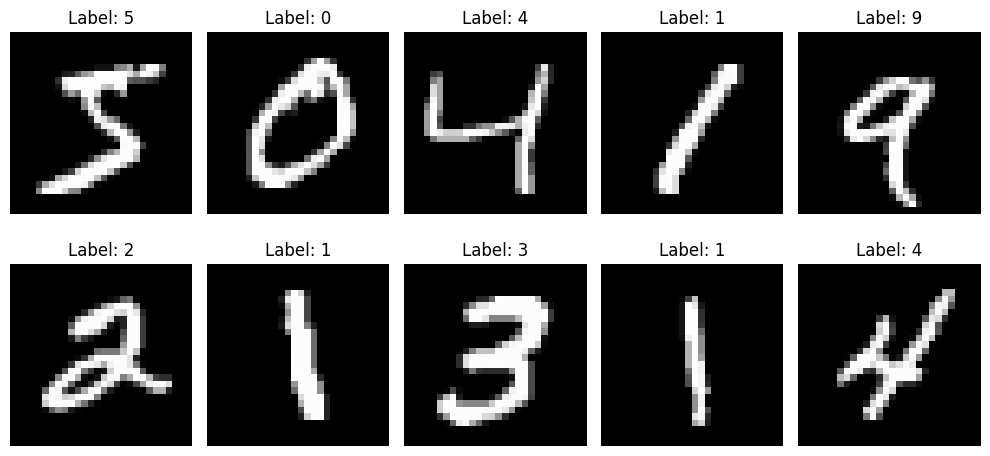

In [32]:
# Display Sample Images
plt.figure(figsize=(10,5))

for i in range(10):
  plt.subplot(2,5,i+1)
  plt.imshow(x_train[i], cmap='gray')
  plt.title(f"Label: {y_train[i]}")
  plt.axis('off')

plt.tight_layout()
plt.show()

In [33]:
# Data Preprocessing
# 1. Reshape iamges for CNN
x_train = x_train.reshape(-1,28,28,1).astype('float32')/255
x_test = x_test.reshape(-1,28,28,1).astype('float32')/255

# 2. One-Hot Encoding
y_train = to_categorical(y_train,10)
y_test = to_categorical(y_test,10)

print("\nAfter Reshaping: ")
print("x_train Shape: ", x_train.shape)
print("y_train Shape: ", y_train.shape)

print("\nOne-Hot Encoded label example: ")
print(y_train[0])


After Reshaping: 
x_train Shape:  (60000, 28, 28, 1)
y_train Shape:  (60000, 10)

One-Hot Encoded label example: 
[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


In [34]:
#  Build CNN model
model = Sequential()
#  First Convolution layer
model.add(
    Conv2D(
        filters=32,
        kernel_size = (3,3),
        activation = 'relu',
        input_shape =(28,28,1)
    )
)
# First Pooling Layer
model.add(MaxPooling2D(pool_size=(2,2)))

#  Second convolution layer
model.add(
    Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation = 'relu'
    )
)
#  Second Pooling Layer
model.add(MaxPooling2D(pool_size=(2,2)))

#  Flatten Layer
model.add(Flatten())

#  Fully Connected Layer
model.add(Dense(128, activation='relu'))

#  Output Layer
model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [35]:
# Model Summary
print("\nCNN Model Architecture")
model.summary()


CNN Model Architecture


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:
#  Compile Model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [37]:
#  train Model
history = model.fit(
    x_train,
    y_train,
    epochs = 5,
    batch_size = 64,
    validation_data = (x_test,y_test)
)

Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 58s 60ms/step - accuracy: 0.9523 - loss: 0.1577 - val_accuracy: 0.9815 - val_loss: 0.0554
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 77s 55ms/step - accuracy: 0.9849 - loss: 0.0487 - val_accuracy: 0.9876 - val_loss: 0.0361
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 51s 55ms/step - accuracy: 0.9900 - loss: 0.0324 - val_accuracy: 0.9887 - val_loss: 0.0329
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 50s 54ms/step - accuracy: 0.9924 - loss: 0.0243 - val_accuracy: 0.9896 - val_loss: 0.0323
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 55s 58ms/step - accuracy: 0.9944 - loss: 0.0185 - val_accuracy: 0.9916 - val_loss: 0.0260


In [38]:
#  Evaluate Model
loss, accuracy = model.evaluate(x_test, y_test)
print("\nTest Loss: ", loss)
print("Test Accuracy: ", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9916 - loss: 0.0260

Test Loss:  0.0260341577231884
Test Accuracy:  0.991599977016449


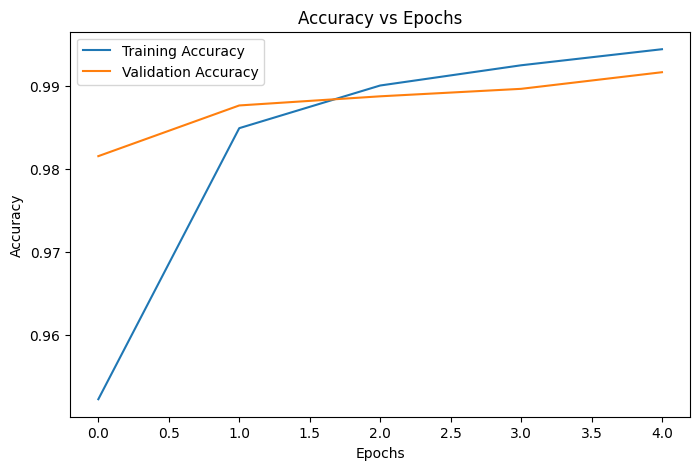

In [39]:
#  Plot Accuracy Graph
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


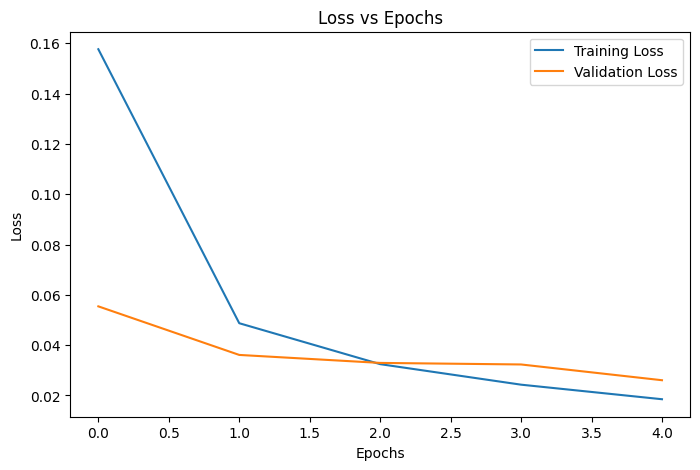

In [40]:
# Plot Loss Graph
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'],label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [41]:
# Make Prediction
index=50
prediction = model.predict(x_test[index:index+1])
predicted_class= np.argmax(prediction)
actual_class = np.argmax(y_test[index])
print("\nPredicted Digit: ", predicted_class)
print("Actual Digit: ", actual_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step

Predicted Digit:  6
Actual Digit:  6


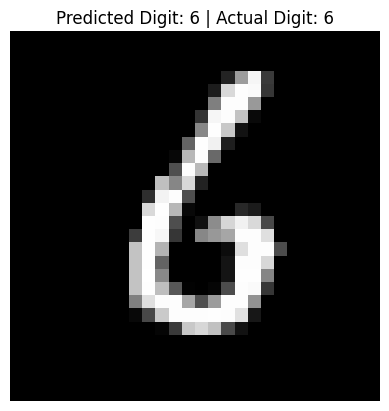

In [42]:
#  Display Predicted Image
plt.imshow(x_test[index].reshape(28,28),cmap='gray')
plt.title(f"Predicted Digit: {predicted_class} | Actual Digit: {actual_class}")
plt.axis('off')
plt.show()

In [44]:
print("Training Images:", x_train.shape)
print("Testing Images:", x_test.shape)

print("Test Accuracy:", accuracy)

Training Images: (60000, 28, 28, 1)
Testing Images: (10000, 28, 28, 1)
Test Accuracy: 0.991599977016449
